# Initialization

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.ticker import FuncFormatter, NullFormatter

from vzr_p2.kv_utils import parse_kv_file
from vzr_p2.notebook import disp, init, savefig

init()
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
df_results = parse_kv_file("results/hpc")
df_results["size_w2"] = df_results["size_w"].pow(2)
df_results["impl"] = pd.Categorical(
    df_results["impl"], categories=["seq", "omp", "cuda"], ordered=True
)
disp(df_results)
df_results_agg = disp(
    df_results.groupby(
        [x for x in df_results.columns if not x.startswith("t_")],
        dropna=False,
    ).mean()
)
df_results_agg_by_size_and_impl = disp(
    df_results_agg.reset_index()
    .pipe(
        lambda df: df[
            (df["impl"] != "cuda") | (df["precision"] == 64)
            # & (df["threads"] == "64x16")
            # & (df["kernel"] == "fused")
            # & (df["toroid"] == "mod")
            # & df["unroll"].isna()
        ]
    )
    .pipe(
        lambda df: df.drop(
            columns=[
                x
                for x in df.columns
                if not (x.startswith("t_") or x in ("impl", "size_w", "size_w2"))
            ]
        )
    )
    # .pipe(
    #     lambda df: df.groupby(
    #         [x for x in df.columns if x in ("impl", "size_w", "size_w2")],
    #         dropna=False,
    #     )
    # )
    # .mean()
)

,opt,impl,size_w,size_h,kernel_size,precision,simd,toroid_impl,steps,dt,t_init,t_upload,t_steps,t_download,t_free,t_work_total,t_total,threads,kernel,toroid,unroll,size_w2
0,3,seq,256,256,26,64,y,halo,100,0.1,0.000092,4.004687e-08,1.101968,2.309680e-07,0.000188,1.101968,1.102248,NaN,NaN,NaN,NaN,65536
1,3,seq,256,256,26,64,y,halo,100,0.1,0.000089,3.026798e-08,1.095743,1.708977e-07,0.000192,1.095743,1.096025,NaN,NaN,NaN,NaN,65536
2,3,seq,256,256,26,64,y,halo,100,0.1,0.000086,2.980232e-08,1.095870,7.078052e-08,0.000168,1.095870,1.096125,NaN,NaN,NaN,NaN,65536
3,3,seq,256,256,26,64,y,halo,100,0.1,0.000085,4.004687e-08,1.098322,4.097819e-07,0.000190,1.098323,1.098598,NaN,NaN,NaN,NaN,65536
4,3,seq,256,256,26,64,y,halo,100,0.1,0.000085,4.097819e-08,1.100100,4.982576e-08,0.000196,1.100100,1.100381,NaN,NaN,NaN,NaN,65536
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1045,3,cuda,4096,4096,26,32,NaN,NaN,100,0.1,0.137273,5.964235e-03,0.612810,5.436806e-03,0.000943,0.624211,0.762427,32x32,fused,mod,NaN,16777216
1046,3,cuda,4096,4096,26,32,NaN,NaN,100,0.1,0.133256,5.641520e-03,0.612788,5.303947e-03,0.000893,0.623734,0.757882,32x32,fused,mod,NaN,16777216
1047,3,cuda,4096,4096,26,32,NaN,NaN,100,0.1,0.133958,5.609851e-03,0.612807,5.459740e-03,0.000968,0.623877,0.758803,32x32,fused,mod,NaN,16777216
1048,3,cuda,4096,4096,26,32,NaN,NaN,100,0.1,0.132216,5.613177e-03,0.612784,5.358991e-03,0.000968,0.623756,0.756940,32x32,fused,mod,NaN,16777216


t_init  \
opt impl size_w size_h kernel_size precision simd toroid_impl steps dt  threads kernel  toroid  unroll size_w2              
3   seq  256    256    26          64        y    halo        100   0.1 NaN     NaN     NaN     NaN    65536     0.000087   
         512    512    26          64        y    halo        100   0.1 NaN     NaN     NaN     NaN    262144    0.000191   
         1024   1024   26          64        y    halo        100   0.1 NaN     NaN     NaN     NaN    1048576   0.000224   
         2048   2048   26          64        y    halo        100   0.1 NaN     NaN     NaN     NaN    4194304   0.000337   
         4096   4096   26          64        y    halo        100   0.1 NaN     NaN     NaN     NaN    16777216  0.000321   
...                                                                                                                   ...   
    cuda 4096   4096   26          64        NaN  NaN         100   0.1 64x16   default mod     NaN    16777216  0.147527   
                                                                                fused   bitwise y      16777216  0.136651   
                                                                                        mod     NaN    16777216  0.143373   
                                                                                shared  bitwise y      16777216  0.140149   
                                                                                        mod     NaN    16777216  0.142558   

                                                                                                                     t_upload  \
opt impl size_w size_h kernel_size precision simd toroid_impl steps dt  threads kernel  toroid  unroll size_w2                  
3   seq  256    256    26          64        y    halo        100   0.1 NaN     NaN     NaN     NaN    65536     3.622845e-08   
         512    512    26          64        y    halo        100   0.1 NaN     NaN     NaN     NaN    262144    5.001202e-08   
         1024   1024   26          64        y    halo        100   0.1 NaN     NaN     NaN     NaN    1048576   3.594905e-08   
         2048   2048   26          64        y    halo        100   0.1 NaN     NaN     NaN     NaN    4194304   3.790483e-08   
         4096   4096   26          64        y    halo        100   0.1 NaN     NaN     NaN     NaN    16777216  4.228205e-08   
...                                                                                                                       ...   
    cuda 4096   4096   26          64        NaN  NaN         100   0.1 64x16   default mod     NaN    16777216  1.120418e-02   
                                                                                fused   bitwise y      16777216  1.099630e-02   
                                                                                        mod     NaN    16777216  1.105658e-02   
                                                                                shared  bitwise y      16777216  1.455062e-02   
                                                                                        mod     NaN    16777216  1.105963e-02   

                                                                                                                    t_steps  \
opt impl size_w size_h kernel_size precision simd toroid_impl steps dt  threads kernel  toroid  unroll size_w2                
3   seq  256    256    26          64        y    halo        100   0.1 NaN     NaN     NaN     NaN    65536       1.098401   
         512    512    26          64        y    halo        100   0.1 NaN     NaN     NaN     NaN    262144      4.376653   
         1024   1024   26          64        y    halo        100   0.1 NaN     NaN     NaN     NaN    1048576    17.533502   
         2048   2048   26          64        y    halo        100   0.1 NaN     NaN     NaN     NaN    4194304    70.254104   
         4096   4096   26          64        y   

,impl,size_w,size_w2,t_init,t_upload,t_steps,t_download,t_free,t_work_total,t_total
0,seq,256,65536,0.000087,3.622845e-08,1.098401,1.864508e-07,0.000187,1.098401,1.098675
1,seq,512,262144,0.000191,5.001202e-08,4.376653,2.301298e-07,0.000325,4.376653,4.377169
2,seq,1024,1048576,0.000224,3.594905e-08,17.533502,2.148561e-07,0.001189,17.533502,17.534915
3,seq,2048,4194304,0.000337,3.790483e-08,70.254104,1.683831e-07,0.003685,70.254105,70.258126
4,seq,4096,16777216,0.000321,4.228205e-08,281.773240,2.665445e-07,0.006268,281.773241,281.779830
...,...,...,...,...,...,...,...,...,...,...
205,cuda,4096,16777216,0.147527,1.120418e-02,2.109061,5.434920e-03,0.001033,2.125700,2.274260
206,cuda,4096,16777216,0.136651,1.099630e-02,0.791131,5.520144e-03,0.001559,0.807648,0.945859
207,cuda,4096,16777216,0.143373,1.105658e-02,0.745183,4.704798e-03,0.001658,0.760945,0.905976
208,cuda,4096,16777216,0.140149,1.455062e-02,0.817715,5.487978e-03,0.001340,0.837754,0.979243


# Scaling comparison

,index,opt,impl,size_w,size_h,kernel_size,precision,simd,toroid_impl,steps,dt,t_init,t_upload,t_steps,t_download,t_free,t_work_total,t_total,threads,kernel,toroid,unroll,size_w2
0,0,3,seq,256,256,26,64,y,halo,100,0.1,0.000092,4.004687e-08,1.101968,2.309680e-07,0.000188,1.101968,1.102248,NaN,NaN,NaN,NaN,65536
1,1,3,seq,256,256,26,64,y,halo,100,0.1,0.000089,3.026798e-08,1.095743,1.708977e-07,0.000192,1.095743,1.096025,NaN,NaN,NaN,NaN,65536
2,2,3,seq,256,256,26,64,y,halo,100,0.1,0.000086,2.980232e-08,1.095870,7.078052e-08,0.000168,1.095870,1.096125,NaN,NaN,NaN,NaN,65536
3,3,3,seq,256,256,26,64,y,halo,100,0.1,0.000085,4.004687e-08,1.098322,4.097819e-07,0.000190,1.098323,1.098598,NaN,NaN,NaN,NaN,65536
4,4,3,seq,256,256,26,64,y,halo,100,0.1,0.000085,4.097819e-08,1.100100,4.982576e-08,0.000196,1.100100,1.100381,NaN,NaN,NaN,NaN,65536
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1045,1045,3,cuda,4096,4096,26,32,NaN,NaN,100,0.1,0.137273,5.964235e-03,0.612810,5.436806e-03,0.000943,0.624211,0.762427,32x32,fused,mod,NaN,16777216
1046,1046,3,cuda,4096,4096,26,32,NaN,NaN,100,0.1,0.133256,5.641520e-03,0.612788,5.303947e-03,0.000893,0.623734,0.757882,32x32,fused,mod,NaN,16777216
1047,1047,3,cuda,4096,4096,26,32,NaN,NaN,100,0.1,0.133958,5.609851e-03,0.612807,5.459740e-03,0.000968,0.623877,0.758803,32x32,fused,mod,NaN,16777216
1048,1048,3,cuda,4096,4096,26,32,NaN,NaN,100,0.1,0.132216,5.613177e-03,0.612784,5.358991e-03,0.000968,0.623756,0.756940,32x32,fused,mod,NaN,16777216


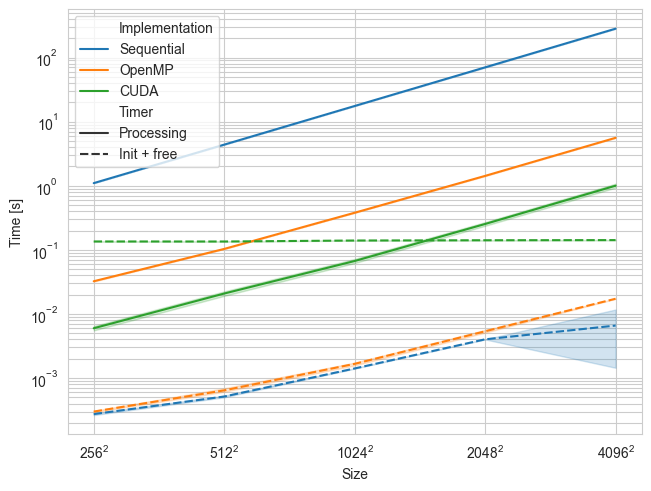

In [3]:
df = df_results.reset_index().pipe(disp)
df = pd.concat(
    [
        df.assign(kind="work", t=df["t_work_total"]),
        df.assign(kind="init", t=df["t_total"] - df["t_work_total"]),
    ]
)
df["kind"] = pd.Categorical(df["kind"], categories=["work", "init"], ordered=True)


def sqrt_squared_formatter(x, pos):
    if x < 0:
        return ""
    r = np.sqrt(x)
    if np.isclose(r, round(r)):
        r = round(r)
    return rf"$\mathregular{{{r}}}^\mathregular{{2}}$"


fig, ax = plt.subplots(layout="compressed")
sns.lineplot(
    ax=ax,
    x=df["size_w2"].rename("Size"),
    y=df["t"].rename("Time [s]"),
    hue=(
        df["impl"]
        .rename("Implementation")
        .map({"seq": "Sequential", "omp": "OpenMP", "cuda": "CUDA"})
    ),
    style=(
        df["kind"].rename("Timer").map({"init": "Init + free", "work": "Processing"})
    ),
)
ax.grid(True, "both", "y")
ax.set_xscale("log", base=2)
ax.set_xticks(df["size_w2"].unique())
ax.xaxis.set_major_formatter(FuncFormatter(sqrt_squared_formatter))
ax.xaxis.set_minor_formatter(NullFormatter())
ax.set_yscale("log")

savefig(fig, "fig/scaling.pdf")

# Block size comparison

,opt,impl,size_w,size_h,kernel_size,precision,simd,toroid_impl,steps,dt,t_init,t_upload,t_steps,t_download,t_free,t_work_total,t_total,threads,kernel,toroid,unroll,size_w2
70,3,cuda,4096,4096,26,64,NaN,NaN,100,0.1,0.132312,0.010875,2.152761,0.004692,0.004713,2.168329,2.305353,16x16,default,mod,NaN,16777216
71,3,cuda,4096,4096,26,64,NaN,NaN,100,0.1,0.135995,0.010879,2.153747,0.005547,0.001140,2.170173,2.307307,16x16,default,mod,NaN,16777216
72,3,cuda,4096,4096,26,64,NaN,NaN,100,0.1,0.140436,0.010889,2.154782,0.005683,0.001034,2.171353,2.312823,16x16,default,mod,NaN,16777216
73,3,cuda,4096,4096,26,64,NaN,NaN,100,0.1,0.144305,0.011224,2.163060,0.004717,0.001051,2.179001,2.324357,16x16,default,mod,NaN,16777216
74,3,cuda,4096,4096,26,64,NaN,NaN,100,0.1,0.156006,0.010896,2.170662,0.004786,0.001053,2.186345,2.343403,16x16,default,mod,NaN,16777216
95,3,cuda,4096,4096,26,64,NaN,NaN,100,0.1,0.131833,0.010966,2.106349,0.005565,0.001055,2.122880,2.255769,16x64,default,mod,NaN,16777216
96,3,cuda,4096,4096,26,64,NaN,NaN,100,0.1,0.140413,0.010906,2.114493,0.004696,0.001037,2.130094,2.271545,16x64,default,mod,NaN,16777216
97,3,cuda,4096,4096,26,64,NaN,NaN,100,0.1,0.139493,0.011215,2.114941,0.005496,0.003033,2.131652,2.274179,16x64,default,mod,NaN,16777216
98,3,cuda,4096,4096,26,64,NaN,NaN,100,0.1,0.136200,0.011347,2.116285,0.004675,0.003548,2.132307,2.272055,16x64,default,mod,NaN,16777216
99,3,cuda,4096,4096,26,64,NaN,NaN,100,0.1,0.139574,0.011209,2.116721,0.005544,0.003589,2.133473,2.276635,16x64,default,mod,NaN,16777216


,opt,impl,size_w,size_h,kernel_size,precision,simd,toroid_impl,steps,dt,t_init,t_upload,t_steps,t_download,t_free,t_work_total,t_total,threads,kernel,toroid,unroll,size_w2
470,3,cuda,4096,4096,26,64,NaN,NaN,100,0.1,0.134888,0.010907,0.733829,0.005382,0.001070,0.750118,0.886077,16x16,fused,mod,NaN,16777216
471,3,cuda,4096,4096,26,64,NaN,NaN,100,0.1,0.136951,0.010913,0.732313,0.005471,0.001057,0.748697,0.886704,16x16,fused,mod,NaN,16777216
472,3,cuda,4096,4096,26,64,NaN,NaN,100,0.1,0.149116,0.011189,0.735103,0.006397,0.001324,0.752689,0.903128,16x16,fused,mod,NaN,16777216
473,3,cuda,4096,4096,26,64,NaN,NaN,100,0.1,0.161412,0.011523,0.739339,0.005586,0.001045,0.756448,0.918905,16x16,fused,mod,NaN,16777216
474,3,cuda,4096,4096,26,64,NaN,NaN,100,0.1,0.145252,0.011369,0.738450,0.005473,0.003810,0.755292,0.904354,16x16,fused,mod,NaN,16777216
495,3,cuda,4096,4096,26,64,NaN,NaN,100,0.1,0.135676,0.011416,0.743642,0.005591,0.001075,0.760649,0.897400,16x64,fused,mod,NaN,16777216
496,3,cuda,4096,4096,26,64,NaN,NaN,100,0.1,0.142060,0.011266,0.748502,0.005609,0.003581,0.765376,0.911017,16x64,fused,mod,NaN,16777216
497,3,cuda,4096,4096,26,64,NaN,NaN,100,0.1,0.144976,0.011332,0.749367,0.005534,0.001061,0.766233,0.912270,16x64,fused,mod,NaN,16777216
498,3,cuda,4096,4096,26,64,NaN,NaN,100,0.1,0.143758,0.011389,0.749628,0.005530,0.001077,0.766547,0.911381,16x64,fused,mod,NaN,16777216
499,3,cuda,4096,4096,26,64,NaN,NaN,100,0.1,0.142222,0.011204,0.748916,0.005529,0.001056,0.765649,0.908927,16x64,fused,mod,NaN,16777216


,opt,impl,size_w,size_h,kernel_size,precision,simd,toroid_impl,steps,dt,t_init,t_upload,t_steps,t_download,t_free,t_work_total,t_total,threads,kernel,toroid,unroll,size_w2
370,3,cuda,4096,4096,26,64,NaN,NaN,100,0.1,0.134008,0.010917,1.049139,0.005516,0.001045,1.065571,1.200624,16x16,fused,bitwise,y,16777216
371,3,cuda,4096,4096,26,64,NaN,NaN,100,0.1,0.130488,0.010876,1.048507,0.005510,0.001032,1.064893,1.196413,16x16,fused,bitwise,y,16777216
372,3,cuda,4096,4096,26,64,NaN,NaN,100,0.1,0.137919,0.011389,1.047677,0.005554,0.001019,1.064620,1.203557,16x16,fused,bitwise,y,16777216
373,3,cuda,4096,4096,26,64,NaN,NaN,100,0.1,0.132389,0.010911,1.048023,0.005432,0.001037,1.064366,1.197792,16x16,fused,bitwise,y,16777216
374,3,cuda,4096,4096,26,64,NaN,NaN,100,0.1,0.131498,0.010879,1.047495,0.005482,0.001048,1.063855,1.196402,16x16,fused,bitwise,y,16777216
395,3,cuda,4096,4096,26,64,NaN,NaN,100,0.1,0.134927,0.010918,0.781603,0.005485,0.001078,0.798006,0.934011,16x64,fused,bitwise,y,16777216
396,3,cuda,4096,4096,26,64,NaN,NaN,100,0.1,0.144718,0.011195,0.783656,0.005532,0.001086,0.800383,0.946187,16x64,fused,bitwise,y,16777216
397,3,cuda,4096,4096,26,64,NaN,NaN,100,0.1,0.145040,0.011215,0.783521,0.005544,0.001060,0.800280,0.946380,16x64,fused,bitwise,y,16777216
398,3,cuda,4096,4096,26,64,NaN,NaN,100,0.1,0.142284,0.011220,0.782418,0.005583,0.001059,0.799221,0.942563,16x64,fused,bitwise,y,16777216
399,3,cuda,4096,4096,26,64,NaN,NaN,100,0.1,0.145409,0.011436,0.784259,0.005497,0.001032,0.801192,0.947633,16x64,fused,bitwise,y,16777216


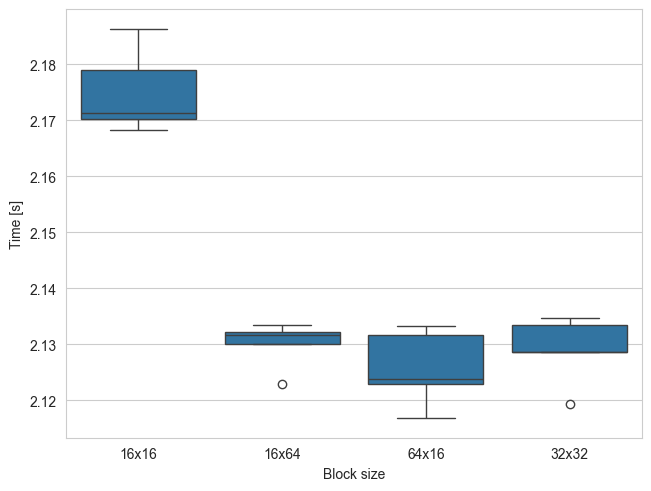

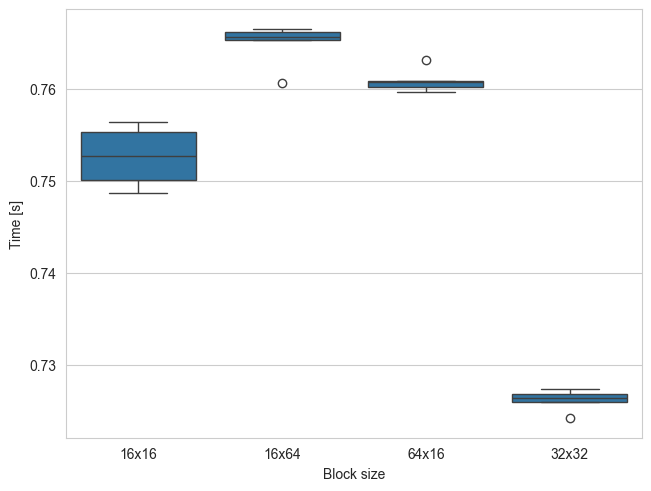

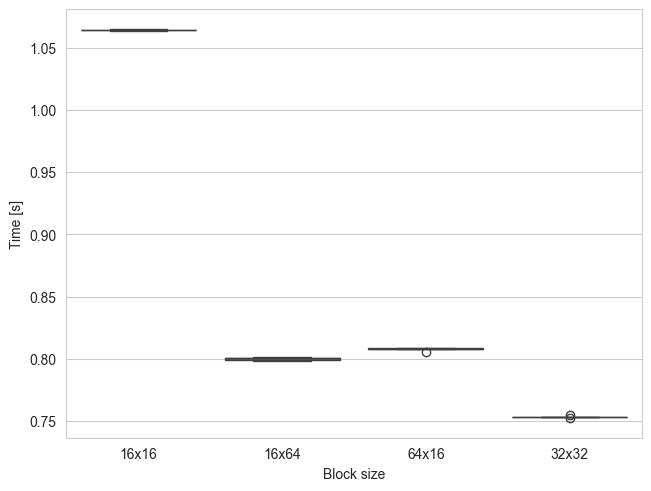

In [4]:
def mk_plot_blocksize(cond):
    df = df_results.pipe(
        lambda df: df[
            (df["impl"] == "cuda")
            & (df["size_w"] == 4096)
            & (df["precision"] == 64)
            & cond(df)
        ]
    ).pipe(disp)

    fig, ax = plt.subplots(layout="compressed")
    sns.boxplot(
        ax=ax,
        x=df["threads"].rename("Block size"),
        y=df["t_work_total"].rename("Time [s]"),
    )

    return fig


savefig(
    mk_plot_blocksize(lambda df: df["kernel"] == "default"),
    "fig/block_default.pdf",
)
savefig(
    mk_plot_blocksize(lambda df: (df["kernel"] == "fused") & df["unroll"].isna()),
    "fig/block_fused_unopt.pdf",
)
savefig(
    mk_plot_blocksize(lambda df: (df["kernel"] == "fused") & ~df["unroll"].isna()),
    "fig/block_fused_opt.pdf",
)

# Kernel comparison

,opt,impl,size_w,size_h,kernel_size,precision,simd,toroid_impl,steps,dt,t_init,t_upload,t_steps,t_download,t_free,t_work_total,t_total,threads,kernel,toroid,unroll,size_w2
145,3,cuda,4096,4096,26,64,NaN,NaN,100,0.1,0.132730,0.010883,2.102914,0.005523,0.001055,2.119320,2.253105,32x32,default,mod,NaN,16777216
146,3,cuda,4096,4096,26,64,NaN,NaN,100,0.1,0.140790,0.011433,2.112409,0.004745,0.001060,2.128587,2.270438,32x32,default,mod,NaN,16777216
147,3,cuda,4096,4096,26,64,NaN,NaN,100,0.1,0.140582,0.011227,2.111871,0.005518,0.001051,2.128616,2.270249,32x32,default,mod,NaN,16777216
148,3,cuda,4096,4096,26,64,NaN,NaN,100,0.1,0.142007,0.011224,2.116666,0.005559,0.001051,2.133449,2.276507,32x32,default,mod,NaN,16777216
149,3,cuda,4096,4096,26,64,NaN,NaN,100,0.1,0.142170,0.011223,2.118053,0.005486,0.004707,2.134762,2.281639,32x32,default,mod,NaN,16777216
245,3,cuda,4096,4096,26,64,NaN,NaN,100,0.1,0.132762,0.011379,0.763498,0.004699,0.000953,0.779576,0.913291,32x32,shared,bitwise,y,16777216
246,3,cuda,4096,4096,26,64,NaN,NaN,100,0.1,0.138187,0.011050,0.765895,0.004513,0.004119,0.781458,0.923763,32x32,shared,bitwise,y,16777216
247,3,cuda,4096,4096,26,64,NaN,NaN,100,0.1,0.139041,0.011062,0.768652,0.005521,0.002906,0.785235,0.927182,32x32,shared,bitwise,y,16777216
248,3,cuda,4096,4096,26,64,NaN,NaN,100,0.1,0.139473,0.011169,0.769137,0.005458,0.001054,0.785764,0.926291,32x32,shared,bitwise,y,16777216
249,3,cuda,4096,4096,26,64,NaN,NaN,100,0.1,0.145069,0.011184,0.769355,0.005553,0.001133,0.786092,0.932295,32x32,shared,bitwise,y,16777216


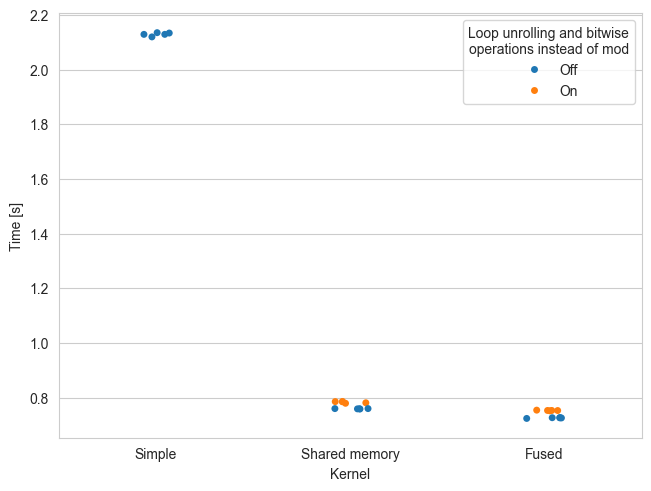

In [5]:
df = df_results.pipe(
    lambda df: df[
        (df["impl"] == "cuda")
        & (df["size_w"] == 4096)
        & (df["precision"] == 64)
        & (df["threads"] == "32x32")
    ]
).pipe(disp)

fig, ax = plt.subplots(layout="compressed")
sns.stripplot(
    ax=ax,
    x=(
        df["kernel"]
        .rename("Kernel")
        .map({"default": "Simple", "shared": "Shared memory", "fused": "Fused"})
    ),
    y=df["t_work_total"].rename("Time [s]"),
    hue=(
        df["toroid"]
        .rename("Loop unrolling and bitwise\noperations instead of mod")
        .map({"mod": "Off", "bitwise": "On"})
    ),
)
ax.legend_.get_title().set_multialignment("center")  # type: ignore
ax.legend_.get_title().set_ha("center")  # type: ignore

savefig(fig, "fig/kernel.pdf")